# Segmentação de Clientes usando K-Means

Este notebook realiza a segmentação de clientes a partir do comportamento de compra calculado na matriz RFM. 
Utilizaremos o algoritmo não supervisionado **K-Means** para agrupar clientes com características semelhantes, permitindo estratégias de marketing personalizadas.

## 1. Importando as Bibliotecas

Carregamos as bibliotecas fundamentais de manipulação de dados, visualização e machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Carregando os Dados Processados

Carregamos a matriz RFM gerada na etapa anterior de EDA.

In [2]:
# Definindo o caminho dos dados processados
data_path = '../data/processed/rfm_data.csv'

rfm_df = pd.read_csv(data_path)
print(f"Shape do dataset RFM: {rfm_df.shape}")
rfm_df.head()

Shape do dataset RFM: (93357, 4)


,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,114,1,27.19
2,0000f46a3911fa3c0805444483337064,536,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,320,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,287,1,196.89


## 3. Aplicação de Regras de Negócio

**Regra de Negócio:** Conforme as diretrizes do projeto, ignoramos qualquer agrupamento ou referência do tipo `'palestra'`, não considerando isso como um cluster válido. 
Faremos um filtro defensivo para remover qualquer ocorrência que contenha a palavra `'palestra'` em quaisquer colunas de texto.

In [3]:
print(f"Linhas antes do filtro de regra de negócio: {len(rfm_df)}")

# Filtragem de forma defensiva em todas as colunas do tipo object
text_cols = rfm_df.select_dtypes(include=['object']).columns
for col in text_cols:
    initial_count = len(rfm_df)
    rfm_df = rfm_df[~rfm_df[col].astype(str).str.contains('palestra', case=False, na=False)]
    filtered_out = initial_count - len(rfm_df)
    if filtered_out > 0:
        print(f"Removidos {filtered_out} registros contendo 'palestra' na coluna '{col}'")

print(f"Linhas após o filtro de regra de negócio: {len(rfm_df)}")

Linhas antes do filtro de regra de negócio: 93357
Linhas após o filtro de regra de negócio: 93357


/tmp/ipykernel_26581/2147205598.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = rfm_df.select_dtypes(include=['object']).columns


## 4. Pré-processamento (Escalonamento)

O K-Means calcula a distância euclidiana entre os pontos do espaço de características. Como as métricas R (dias), F (quantidade) e M (dinheiro) estão em escalas muito distintas, devemos padronizar os dados com média 0 e desvio padrão 1 utilizando o `StandardScaler`.

In [4]:
# Selecionando as variáveis para clusterização
features = ['recency', 'frequency', 'monetary']
X = rfm_df[features]

# Inicializando e ajustando o Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Criando um DataFrame auxiliar com as variáveis escalonadas
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.head()

,recency,frequency,monetary
0,-0.825362,-0.15983,-0.102949
1,-0.805701,-0.15983,-0.609813
2,1.959998,-0.15983,-0.348980
3,0.544379,-0.15983,-0.537214
4,0.328104,-0.15983,0.140033


## 5. Seleção do Número de Clusters (k)

Para encontrar o melhor valor de $k$, aplicamos dois métodos diagnósticos:
1. **Método do Cotovelo (Elbow Method):** Avalia a inércia (soma das distâncias quadradas intracluster) para diferentes valores de $k$.
2. **Silhouette Score:** Avalia a coesão e separação dos clusters. Como a métrica é computacionalmente cara para ~93k linhas, utilizaremos uma amostragem aleatória representativa de 15.000 clientes para este cálculo.

In [5]:
k_values = list(range(2, 10))
inertias = []
silhouettes = []

# Amostragem aleatória para o cálculo do Silhouette Score
sample_size = min(15000, len(rfm_df))
np.random.seed(42)
sample_idx = np.random.choice(len(rfm_df), sample_size, replace=False)
X_scaled_sample = X_scaled[sample_idx]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    
    # Silhouette Score calculado na amostra
    score = silhouette_score(X_scaled_sample, kmeans.labels_[sample_idx])
    silhouettes.append(score)
    print(f"k = {k} | Inércia = {kmeans.inertia_:.2f} | Silhouette Score = {score:.4f}")

k = 2 | Inércia = 201657.61 | Silhouette Score = 0.7300


k = 3 | Inércia = 137739.55 | Silhouette Score = 0.4593


k = 4 | Inércia = 92096.82 | Silhouette Score = 0.4915


k = 5 | Inércia = 77433.28 | Silhouette Score = 0.4189


k = 6 | Inércia = 63550.19 | Silhouette Score = 0.4354


k = 7 | Inércia = 54081.23 | Silhouette Score = 0.4356


k = 8 | Inércia = 48241.96 | Silhouette Score = 0.4429


k = 9 | Inércia = 43724.39 | Silhouette Score = 0.3823


### Gráficos Diagnósticos: Cotovelo & Silhouette

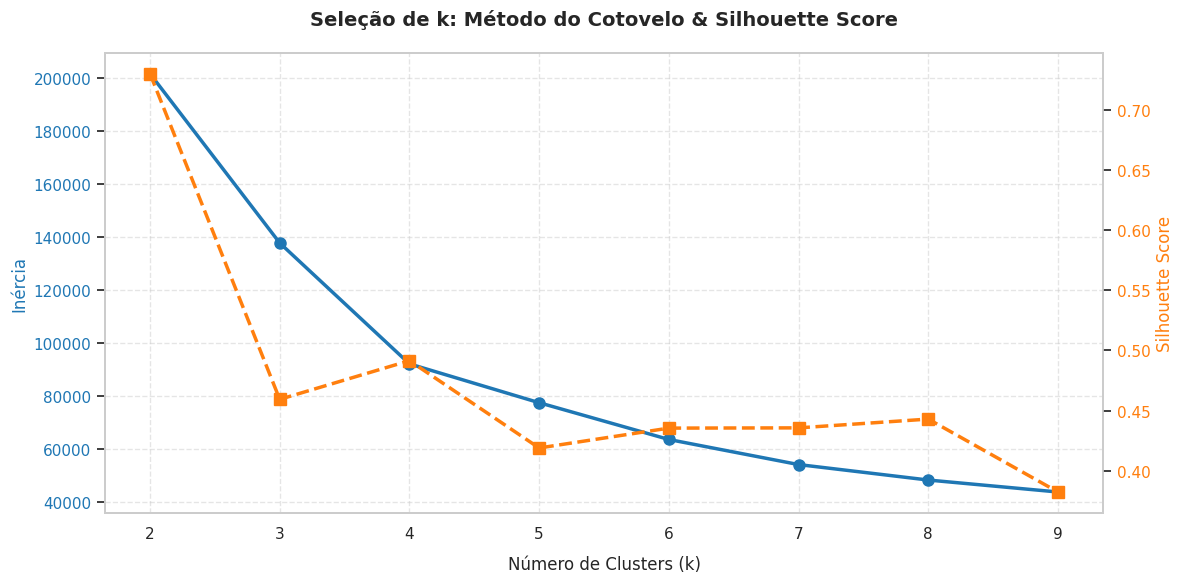

In [6]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot da Inércia (Método do Cotovelo)
color = '#1f77b4'
ax1.set_xlabel('Número de Clusters (k)', fontsize=12, labelpad=10)
ax1.set_ylabel('Inércia', color=color, fontsize=12)
ax1.plot(k_values, inertias, marker='o', color=color, linewidth=2.5, markersize=8, label='Inércia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Eixo secundário para o Silhouette Score
ax2 = ax1.twinx()
color = '#ff7f0e'
ax2.set_ylabel('Silhouette Score', color=color, fontsize=12)
ax2.plot(k_values, silhouettes, marker='s', color=color, linewidth=2.5, markersize=8, linestyle='--', label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)
ax2.grid(False) # Evita sobreposição de grades

plt.title('Seleção de k: Método do Cotovelo & Silhouette Score', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()
plt.show()

## 6. Modelo K-Means Final

Com base nos resultados obtidos:
- $k=2$ tem o maior Silhouette Score (0.73), mas divide os clientes de maneira muito genérica.
- $k=4$ apresenta um pico local no Silhouette Score (0.49) e uma quebra nítida (cotovelo) na inércia, sendo a escolha ideal para extrair personas de negócio significativas.

Aplicamos o K-Means com **$k=4$**.

In [7]:
k_ideal = 4
kmeans_final = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
rfm_df['cluster_id'] = kmeans_final.fit_predict(X_scaled)

print("Distribuição de Clientes por Cluster:")
print(rfm_df['cluster_id'].value_counts().sort_index())

Distribuição de Clientes por Cluster:
cluster_id
0    50643
1    37526
2     2772
3     2416
Name: count, dtype: int64


## 7. Perfil de Negócio dos Clusters

Calculamos a média de Recência, Frequência e Valor Monetário para cada cluster a fim de traçar seus perfis e denominá-los.

In [8]:
cluster_profile = rfm_df.groupby('cluster_id').agg(
    Contagem=('customer_unique_id', 'count'),
    Recencia_Media=('recency', 'mean'),
    Frequencia_Media=('frequency', 'mean'),
    Monetario_Medio=('monetary', 'mean')
).reset_index()

# Cálculo da porcentagem de representação de cada cluster
cluster_profile['Percentual_%'] = (cluster_profile['Contagem'] / cluster_profile['Contagem'].sum() * 100).round(2)
cluster_profile.sort_values(by='Monetario_Medio', ascending=False)

,cluster_id,Contagem,Recencia_Media,Frequencia_Media,Monetario_Medio,Percentual_%
3,3,2416,238.463576,1.012831,1161.325940,2.59
2,2,2772,219.443723,2.114358,289.680253,2.97
0,0,50643,127.073060,1.000000,134.376975,54.25
1,1,37526,386.396365,1.000000,133.466171,40.20


## 8. Visualização Gráfica da Separação dos Clusters

Apresentamos a separação através de dois gráficos complementares:
1. **Seaborn Pairplot:** Visualização de dispersões bivariadas das variáveis RFM.
2. **Matplotlib 3D Scatter:** Visualização tridimensional inter-relação das três variáveis numéricas.

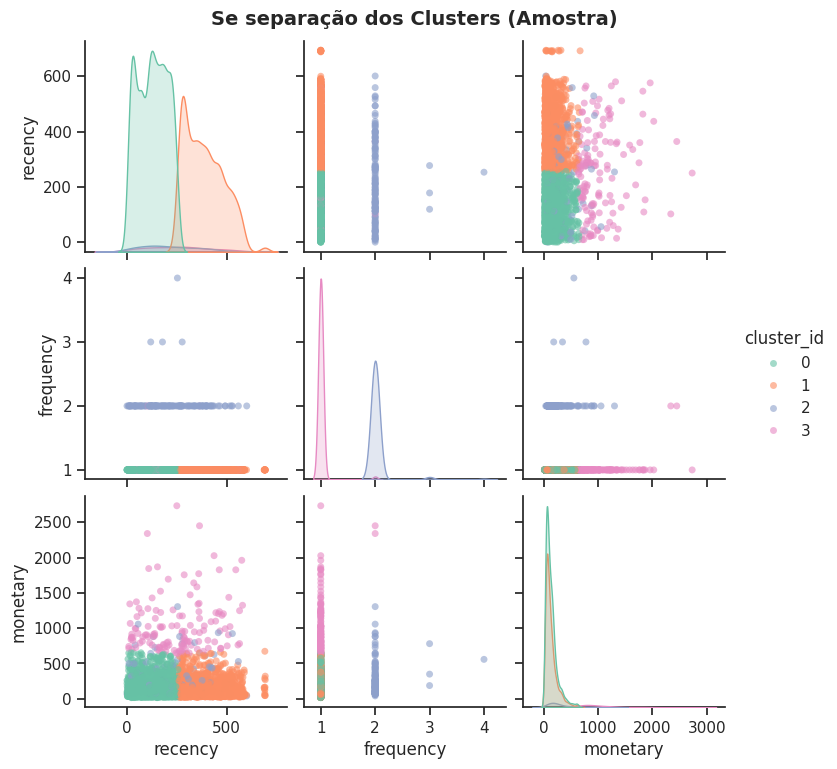

In [9]:
# 1. Pairplot de variáveis do RFM
sns.set_theme(style="ticks")
palette = sns.color_palette("Set2", n_colors=k_ideal)

# Amostramos 5000 registros para evitar travamento do plot
pairplot_df = rfm_df.sample(n=min(5000, len(rfm_df)), random_state=42)

g = sns.pairplot(
    pairplot_df, 
    vars=['recency', 'frequency', 'monetary'], 
    hue='cluster_id', 
    palette=palette, 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'edgecolor': 'none', 's': 25}
)
g.fig.suptitle('Se separação dos Clusters (Amostra)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

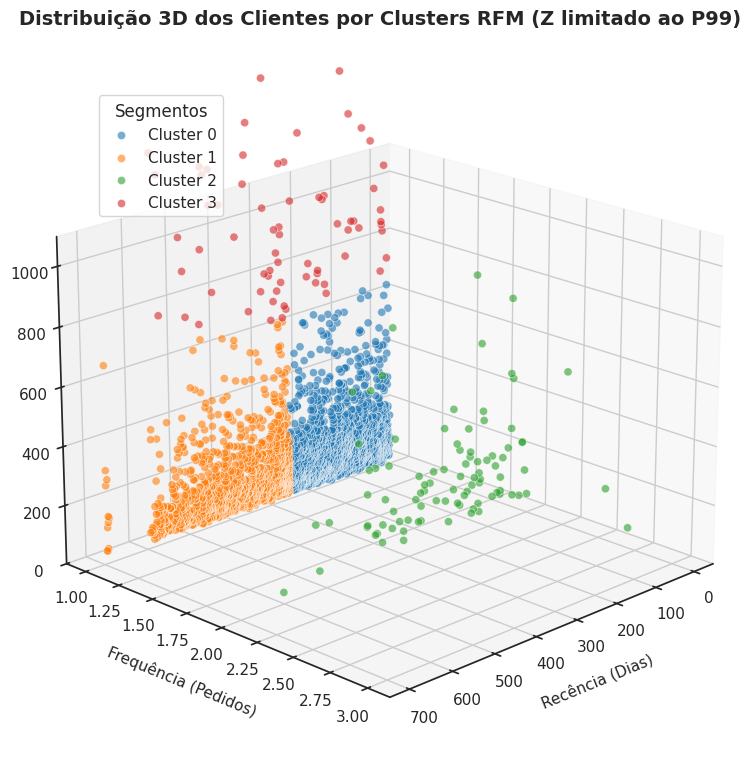

In [10]:
# 2. Gráfico 3D Matplotlib
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Amostra para plot 3D
plot_sample = rfm_df.sample(n=min(3000, len(rfm_df)), random_state=42)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for cluster in range(k_ideal):
    cluster_data = plot_sample[plot_sample['cluster_id'] == cluster]
    ax.scatter(
        cluster_data['recency'], 
        cluster_data['frequency'], 
        cluster_data['monetary'], 
        c=colors[cluster], 
        label=f'Cluster {cluster}', 
        s=35, 
        alpha=0.6,
        edgecolors='w',
        linewidth=0.5
    )

ax.set_xlabel('Recência (Dias)', fontsize=11, labelpad=10)
ax.set_ylabel('Frequência (Pedidos)', fontsize=11, labelpad=10)
ax.set_zlabel('Monetário (Valor Gasto R$)', fontsize=11, labelpad=10)

# Limitando o valor monetário ao percentil 99 para evitar distorção visual devido a outliers extremos
z_lim = rfm_df['monetary'].quantile(0.99)
ax.set_zlim(0, z_lim)

plt.title('Distribuição 3D dos Clientes por Clusters RFM (Z limitado ao P99)', fontsize=14, fontweight='bold', pad=20)
ax.legend(title="Segmentos", loc='upper left', bbox_to_anchor=(0.1, 0.95))

ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

## 9. Exportando o DataFrame Finalizado

Exportamos o DataFrame finalizado com os rótulos de cluster no arquivo `rfm_clusters.csv` na pasta de dados processados.

In [11]:
output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'rfm_clusters.csv')

rfm_df.to_csv(output_file, index=False)
print(f"DataFrame clusterizado salvo com sucesso em: {output_file}")

DataFrame clusterizado salvo com sucesso em: ../data/processed/rfm_clusters.csv
